# Customer Churn Prediction

## PREPROCESS

### 1. IMPORT REQUIRE MODULE

In [39]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
import json 
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC 
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report )
import joblib,tqdm

#### 1.A. FUNCTION AND CONSTANT DEFINATIONS 

In [40]:
def view(y_test,y_pred,model):
    print("---------------------------------------------------------------------")
    print(f"\t-----------------{model}------------------")
    print("\t\t\t _______________________")
    print(f"\t\t\t|  Accuracy : { np.round(accuracy_score(y_test, y_pred)*100)}%\t|")
    print(f"\t\t\t|  Precision: {  np.round(precision_score(y_test, y_pred)*100)}%\t|") 
    print(f"\t\t\t|  Recall : {np.round(recall_score(y_test, y_pred)*100)}%\t|")
    print(f"\t\t\t|  F1 Score : {  np.round(f1_score(y_test, y_pred)*100)}%\t|")
    print("\t\t\t| _____________________ |")

### 2. LOADING DATAFRAME

In [41]:
df=pd.read_csv("data/Telecom_data.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### 3. DUPLICATE AND NULL REMOVE

In [42]:
df.drop(inplace=True) if df.duplicated().sum()>0 else None
for i in df.columns:
    print(i," => ",df[i].isnull().sum())

customerID  =>  0
gender  =>  0
SeniorCitizen  =>  0
Partner  =>  0
Dependents  =>  0
tenure  =>  0
PhoneService  =>  0
MultipleLines  =>  0
InternetService  =>  0
OnlineSecurity  =>  0
OnlineBackup  =>  0
DeviceProtection  =>  0
TechSupport  =>  0
StreamingTV  =>  0
StreamingMovies  =>  0
Contract  =>  0
PaperlessBilling  =>  0
PaymentMethod  =>  0
MonthlyCharges  =>  0
TotalCharges  =>  0
Churn  =>  0


### 4. CHECKING SIMPLE INSIGHT

In [43]:
print("\t\t---------------- Info of Dataset ------------------------")
df.info()
print("\t\t---------------- Statistics Info of Table ----------------")
df.describe()
#plt.savefig("ad")

		---------------- Info of Dataset ------------------------
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str   

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 5. PLOT GRAPH 

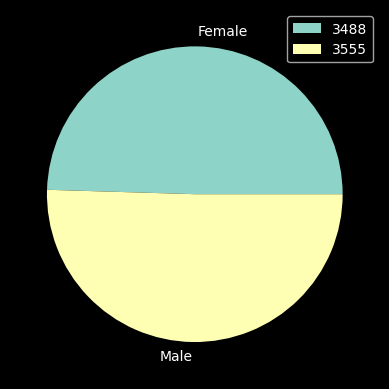

In [44]:
plt.style.use('dark_background')
pol=df.groupby("gender")['Churn'].count()
pol.plot(kind="pie")
plt.legend(pol)
plt.savefig("img/gender-churn")

In [45]:
for i in df.columns:
    print(f"\t------------------- {i} ----------------------")
    print(df[i].head())


	------------------- customerID ----------------------
0    7590-VHVEG
1    5575-GNVDE
2    3668-QPYBK
3    7795-CFOCW
4    9237-HQITU
Name: customerID, dtype: str
	------------------- gender ----------------------
0    Female
1      Male
2      Male
3      Male
4    Female
Name: gender, dtype: str
	------------------- SeniorCitizen ----------------------
0    0
1    0
2    0
3    0
4    0
Name: SeniorCitizen, dtype: int64
	------------------- Partner ----------------------
0    Yes
1     No
2     No
3     No
4     No
Name: Partner, dtype: str
	------------------- Dependents ----------------------
0    No
1    No
2    No
3    No
4    No
Name: Dependents, dtype: str
	------------------- tenure ----------------------
0     1
1    34
2     2
3    45
4     2
Name: tenure, dtype: int64
	------------------- PhoneService ----------------------
0     No
1    Yes
2    Yes
3     No
4    Yes
Name: PhoneService, dtype: str
	------------------- MultipleLines ----------------------
0    No phone ser

### 6. TYPECAST

In [46]:
df.TotalCharges=pd.to_numeric(df.TotalCharges
              ,errors="coerce" )

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 7. MAPPING STRING DATA TO NUMBER

In [48]:

mapper = {}
df.drop("TotalCharges",axis=1,inplace=True)
for col in df.columns[1:]:
    if df[col].dtype == "string":
        unique_values = df[col].unique()

        mapper[col] = {
            value: idx + 1
            for idx, value in enumerate(unique_values)
        }

        df[col] = df[col].map(mapper[col])

### 8. NORMALIZION

In [49]:
#for i in df.columns:
#    scaler.append(StandardScaler())
#    df[i]=scaler[-1].fit_transform([df[i]])[0]
scaler={"min":list(df.iloc[:,1:].min()),"max":list(df.iloc[:,1:].max())}
j=0
for i in df.columns[1:]:
    df[i]=(df[i]-scaler['min'][j])/(scaler['max'][j]-scaler['min'][j])
    j+=1
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,7590-VHVEG,0.0,0.0,0.0,0.0,0.013889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.115423,0.0
1,5575-GNVDE,1.0,0.0,1.0,0.0,0.472222,1.0,0.5,0.0,0.5,0.5,0.5,0.0,0.0,0.0,0.5,1.0,0.333333,0.385075,0.0
2,3668-QPYBK,1.0,0.0,1.0,0.0,0.027778,1.0,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.354229,1.0
3,7795-CFOCW,1.0,0.0,1.0,0.0,0.625000,0.0,0.0,0.0,0.5,0.5,0.5,0.5,0.0,0.0,0.5,1.0,0.666667,0.239303,0.0
4,9237-HQITU,0.0,0.0,1.0,0.0,0.027778,1.0,0.5,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.521891,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1.0,0.0,0.0,1.0,0.333333,1.0,1.0,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.0,0.333333,0.662189,0.0
7039,2234-XADUH,0.0,0.0,0.0,1.0,1.000000,1.0,1.0,0.5,0.0,0.0,0.5,0.0,0.5,0.5,0.5,0.0,1.000000,0.845274,0.0
7040,4801-JZAZL,0.0,0.0,0.0,1.0,0.152778,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.112935,0.0
7041,8361-LTMKD,1.0,1.0,0.0,0.0,0.055556,1.0,1.0,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.558706,1.0


### 9. SPLIT DATASET INTO TEST AND TRAIN

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    df.iloc[:,1:-1],
    df.iloc[:,-1],
    test_size=0.1,
    random_state=42
)

### 10. SAVE THE DATA CONFIG

In [51]:
mapper['scaler']=scaler
with open("config/logic_config.json" ,"w") as fp:
    k=json.dump(mapper,fp)


## LOGISTIC REGRESSION

### 1# TRAIN AND TEST LOGISTIC MODEL

In [52]:
model=LogisticRegression()
model.fit(X_train.iloc[:,:],y_train)
y_pred=model.predict(X_test.iloc[:,:])


### 2# LOGISTIC PARAMETER

In [53]:
model.coef_
model.intercept_

array([0.07136014])

### 3# SAVE LOGISTIC LEARNNIG PARAMETER 

In [54]:
para=np.append(model.intercept_,model.coef_)
np.save("model/logic_model.npy",para)

### 4# CREATE OWEN LOGISTIC MODEL ,LOAD AND TEST

In [55]:
class Logistic:
    def __init__(self):
        self.coef_=None
        self.intercept_=None
    def predict(self,inp):
        linear=np.dot(inp,self.coef_)+self.intercept_
        exp=1/(1+np.exp(-linear))>0.5
        return exp
model2=Logistic()
red=np.load("model/logic_model.npy")
model2.intercept_=red[0]
model2.coef_=red[1:]
ly_pred=model2.predict(X_test.iloc[:,:])
view(y_test,ly_pred,"Logistic Regression")

---------------------------------------------------------------------
	-----------------Logistic Regression------------------
			 _______________________
			|  Accuracy : 82.0%	|
			|  Precision: 69.0%	|
			|  Recall : 60.0%	|
			|  F1 Score : 64.0%	|
			| _____________________ |


## Decision Tree

### 1. LEARNING

In [56]:
dtree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion="gini",
    random_state=42,
    
)
dtree = dtree.fit(X_train.iloc[:,:], y_train)


### 2. TESTING

In [57]:
ty_pred=dtree.predict(X_test.iloc[:,:])
view(y_test,ty_pred,"Decision Tree")

---------------------------------------------------------------------
	-----------------Decision Tree------------------
			 _______________________
			|  Accuracy : 81.0%	|
			|  Precision: 72.0%	|
			|  Recall : 49.0%	|
			|  F1 Score : 58.0%	|
			| _____________________ |


### 3. PLOTING 

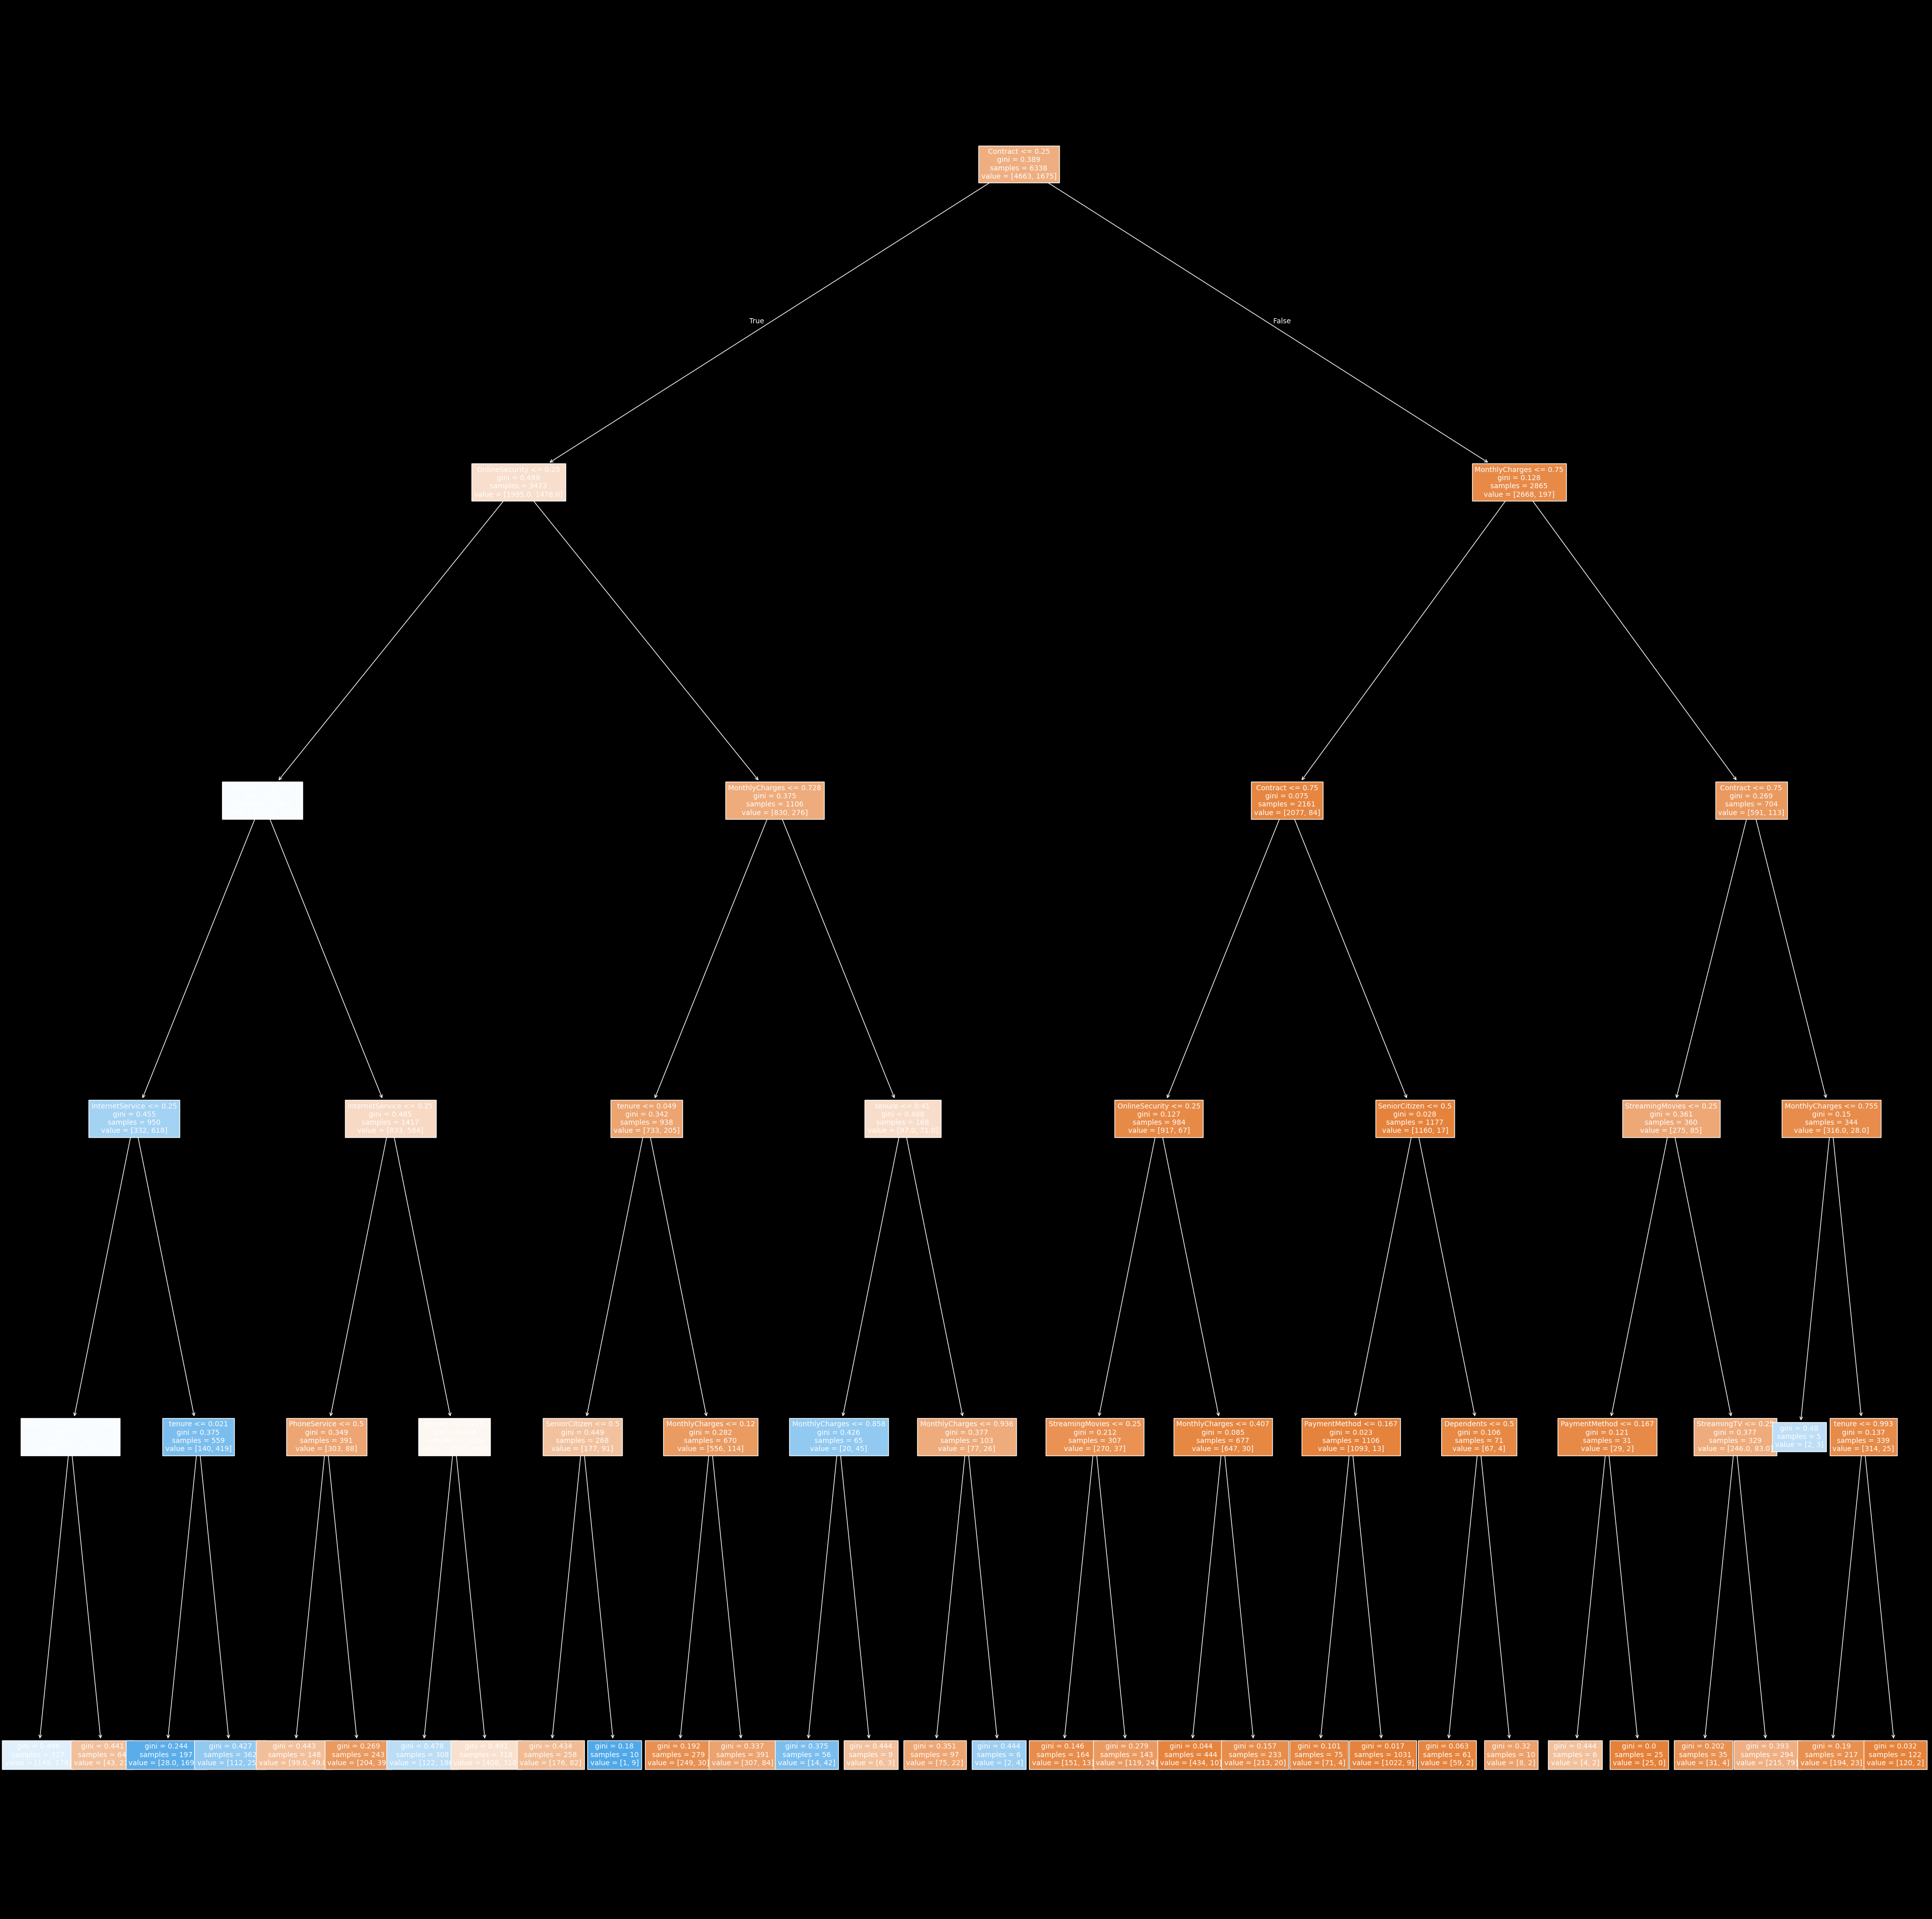

In [58]:
plt.figure(figsize=(49, 49))
tree.plot_tree(dtree,feature_names=X_train.columns,fontsize=10,filled=True)
plt.savefig("img/decision_tree")

## SUPPORT VECTOR CLASSIFICATION

### 1. TRAINING

In [64]:
svc = SVC(
    C=1.0,
    kernel="linear",
    gamma="scale"
)
svc.fit(X=X_train,y=y_train)

SVC(kernel='linear')

### 2. TESTING

In [67]:
sy_pred=svc.predict(X=X_test)
view(y_test,sy_pred,"Support Vector Classification")


---------------------------------------------------------------------
	-----------------Support Vector Classification------------------
			 _______________________
			|  Accuracy : 82.0%	|
			|  Precision: 69.0%	|
			|  Recall : 61.0%	|
			|  F1 Score : 65.0%	|
			| _____________________ |


### 3. SAVE MODEL PARAMETERS

In [73]:
paramters=np.append(svc.intercept_,svc.coef_)
np.save("model/svc_model.npy",paramters)

### 4. LOAD AND TESTING AGAIN

In [79]:
class SVC_const:
    def __init__(self):
        self.coef_=None
        self.intercept_=None
    def predict(self,inp):
        linear=np.dot(inp,self.coef_)+self.intercept_
        svc=linear>0
        return svc
svc_=SVC_const()
paramters=np.load("model/svc_model.npy")
svc_.coef_=paramters[1:]
svc_.intercept_=paramters[0]
sy_pred_=svc_.predict(X_test)
view(y_test,sy_pred_,"SVC Const")

---------------------------------------------------------------------
	-----------------SVC Const------------------
			 _______________________
			|  Accuracy : 82.0%	|
			|  Precision: 69.0%	|
			|  Recall : 61.0%	|
			|  F1 Score : 65.0%	|
			| _____________________ |


## COMPARING MODEL

In [68]:
view(y_test,ly_pred,"Logistic Regression")
view(y_test,ty_pred,"Decision Tree")
view(y_test,sy_pred,"Support Vector Classification")

---------------------------------------------------------------------
	-----------------Logistic Regression------------------
			 _______________________
			|  Accuracy : 82.0%	|
			|  Precision: 69.0%	|
			|  Recall : 60.0%	|
			|  F1 Score : 64.0%	|
			| _____________________ |
---------------------------------------------------------------------
	-----------------Decision Tree------------------
			 _______________________
			|  Accuracy : 81.0%	|
			|  Precision: 72.0%	|
			|  Recall : 49.0%	|
			|  F1 Score : 58.0%	|
			| _____________________ |
---------------------------------------------------------------------
	-----------------Support Vector Classification------------------
			 _______________________
			|  Accuracy : 82.0%	|
			|  Precision: 69.0%	|
			|  Recall : 61.0%	|
			|  F1 Score : 65.0%	|
			| _____________________ |
